In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/20"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第20章 拡散モデル (Diffusion Models)
# 20.1 前向きエンコーダ (Forward Encoder)

本ノートブックでは、『深層学習：基礎と概念 (Christopher M. Bishop & Hugh Bishop 著, Springer 2024)』第20章「拡散モデル」の第1節「前向きエンコーダ (Forward Encoder)」の理論的背景、数式展開の途中計算、およびPythonによる数値実装・シミュレーションを徹底解説します。

---

## 本節のアジェンダと網羅する小節
1. **20.1.1 拡散カーネル (Diffusion kernel)**
   - ガウス拡散カーネル $q(\mathbf{z}_t \mid \mathbf{z}_{t-1})$ の定義 (式 20.1)
   - マルコフ連鎖による前向き軌道の結合確率密度 (式 20.2)
   - ノイズスケジュール（線形スケジュールとコサインスケジュール）
   - 大刻み幅における逆分布の多峰性と微小刻み幅（$\beta_t \to 0$）におけるガウス性（Feller の定理）
   - 教科書図版の完全再現: **Figure 20.1**, **Figure 20.2**, **Figure 20.3**, **Figure 20.4**
2. **20.1.2 条件付き分布 (Conditional distribution)**
   - 累積分散係数 $\alpha_t, \bar{\alpha}_t$ の導入 (式 20.3, 20.4)
   - 任意ステップ $t$ への直接サンプリング公式 $q(\mathbf{z}_t \mid \mathbf{x})$ の数学的帰納法による完全証明 (式 20.5, 20.6)
   - 信号対雑音比 (Signal-to-Noise Ratio: $\text{SNR}(t)$) の推移
   - データ $\mathbf{x}$ で条件付けた解析的事後分布 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x})$ の厳密な平方完成導出 (式 20.7 〜 20.9)


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.forward_encoder import (
    NoiseSchedule,
    LinearNoiseSchedule,
    CosineNoiseSchedule,
    ForwardDiffusionEncoder,
    evaluate_true_reverse_distribution,
    generate_figure_20_1,
    generate_figure_20_2,
    generate_figure_20_3,
    generate_figure_20_4,
    generate_all_section_20_1_figures,
)

setup_style()
print("第20章 前向きエンコーダモジュールが正常に読み込まれました。")


第20章 前向きエンコーダモジュールが正常に読み込まれました。


---

### 20.1.1 拡散カーネル (Diffusion kernel)

#### 1. 前向きマルコフ過程の基礎定式化
拡散モデル（Diffusion Models）における前向きプロセス（Forward Encoder）は、訓練データ $\mathbf{x} = \mathbf{z}_0 \in \mathbb{R}^D$ に対して、時刻 $t = 1, \dots, T$ にわたって段階的にガウスノイズを注入し、最終的に純粋な等方性ガウスノイズ $\mathcal{N}(\mathbf{0}, \mathbf{I})$ へと変換する**固定されたパラメータなしのマルコフ連鎖（Markov Chain）**です。

各ステップの遷移確率は、以下の**拡散カーネル（Diffusion Kernel）**で定義されます：

$$
q(\mathbf{z}_t \mid \mathbf{z}_{t-1}) = \mathcal{N}\left( \mathbf{z}_t \;\middle|\; \sqrt{1 - \beta_t}\mathbf{z}_{t-1}, \, \beta_t \mathbf{I} \right) \tag{20.1}
$$

ここで $\beta_1, \beta_2, \dots, \beta_T$ はあらかじめ定められた分散スケジュール（Noise Schedule）であり、$0 < \beta_t < 1$ を満たします。
平均ベクトルのスケール係数 $\sqrt{1 - \beta_t}$ は、ノイズ注入に伴って変数の分散が発散することを防ぎ、潜在変数のノルム（分散）が各ステップでほぼ一定に保たれるよう正規化（分散保存: Variance Preserving）する役割を果たします。

マルコフ性（Markov Property）により、データ $\mathbf{x}$ が与えられたときの前向き軌道全体の結合分布は以下のように因数分解されます：

$$
q(\mathbf{z}_{1:T} \mid \mathbf{x}) = \prod_{t=1}^T q(\mathbf{z}_t \mid \mathbf{z}_{t-1}) \tag{20.2}
$$

ただし表記の簡潔化のため $\mathbf{z}_0 \equiv \mathbf{x}$ と定めます。

#### 2. 確率グラフィカルモデル (Figure 20.2)
前向きプロセスは推論器（Encoder）として機能しますが、VAE とは異なり**学習すべきニューラルネットワークパラメータを持ちません**。
これに対して、逆向きプロセス（Reverse Decoder）$p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w})$ はニューラルネットワークによってパラメータ化され、純粋なノイズ $\mathbf{z}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ からデータを反復的に復元する生成モデルとなります。


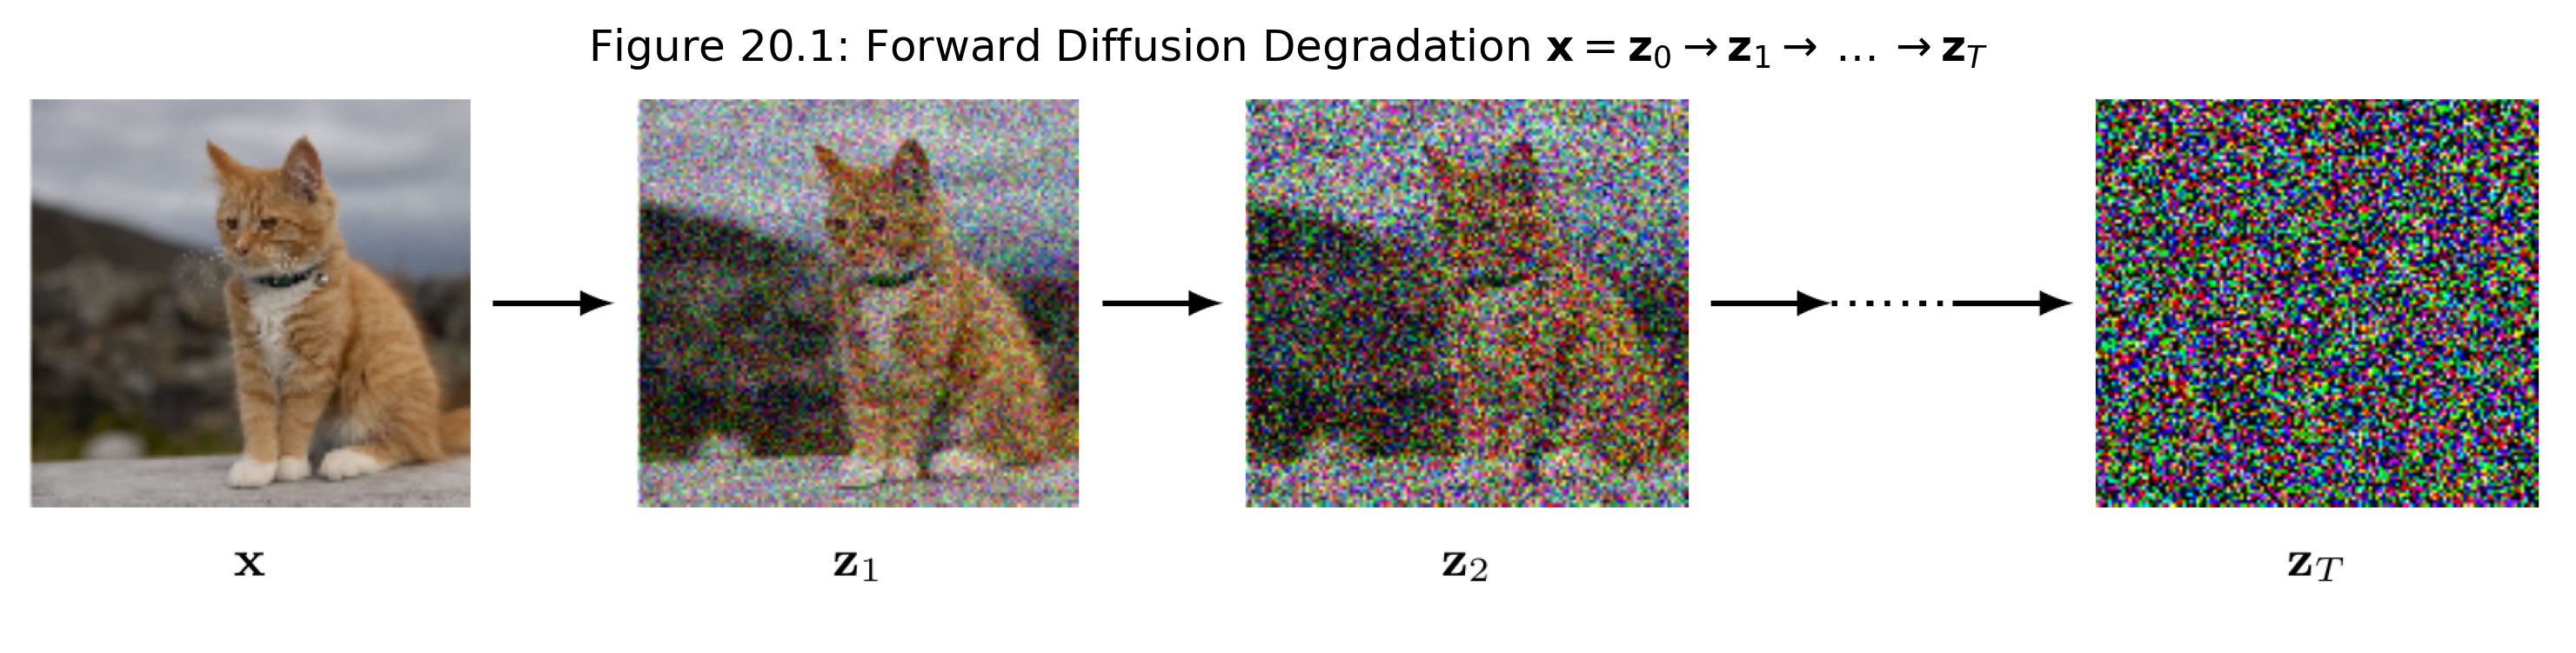

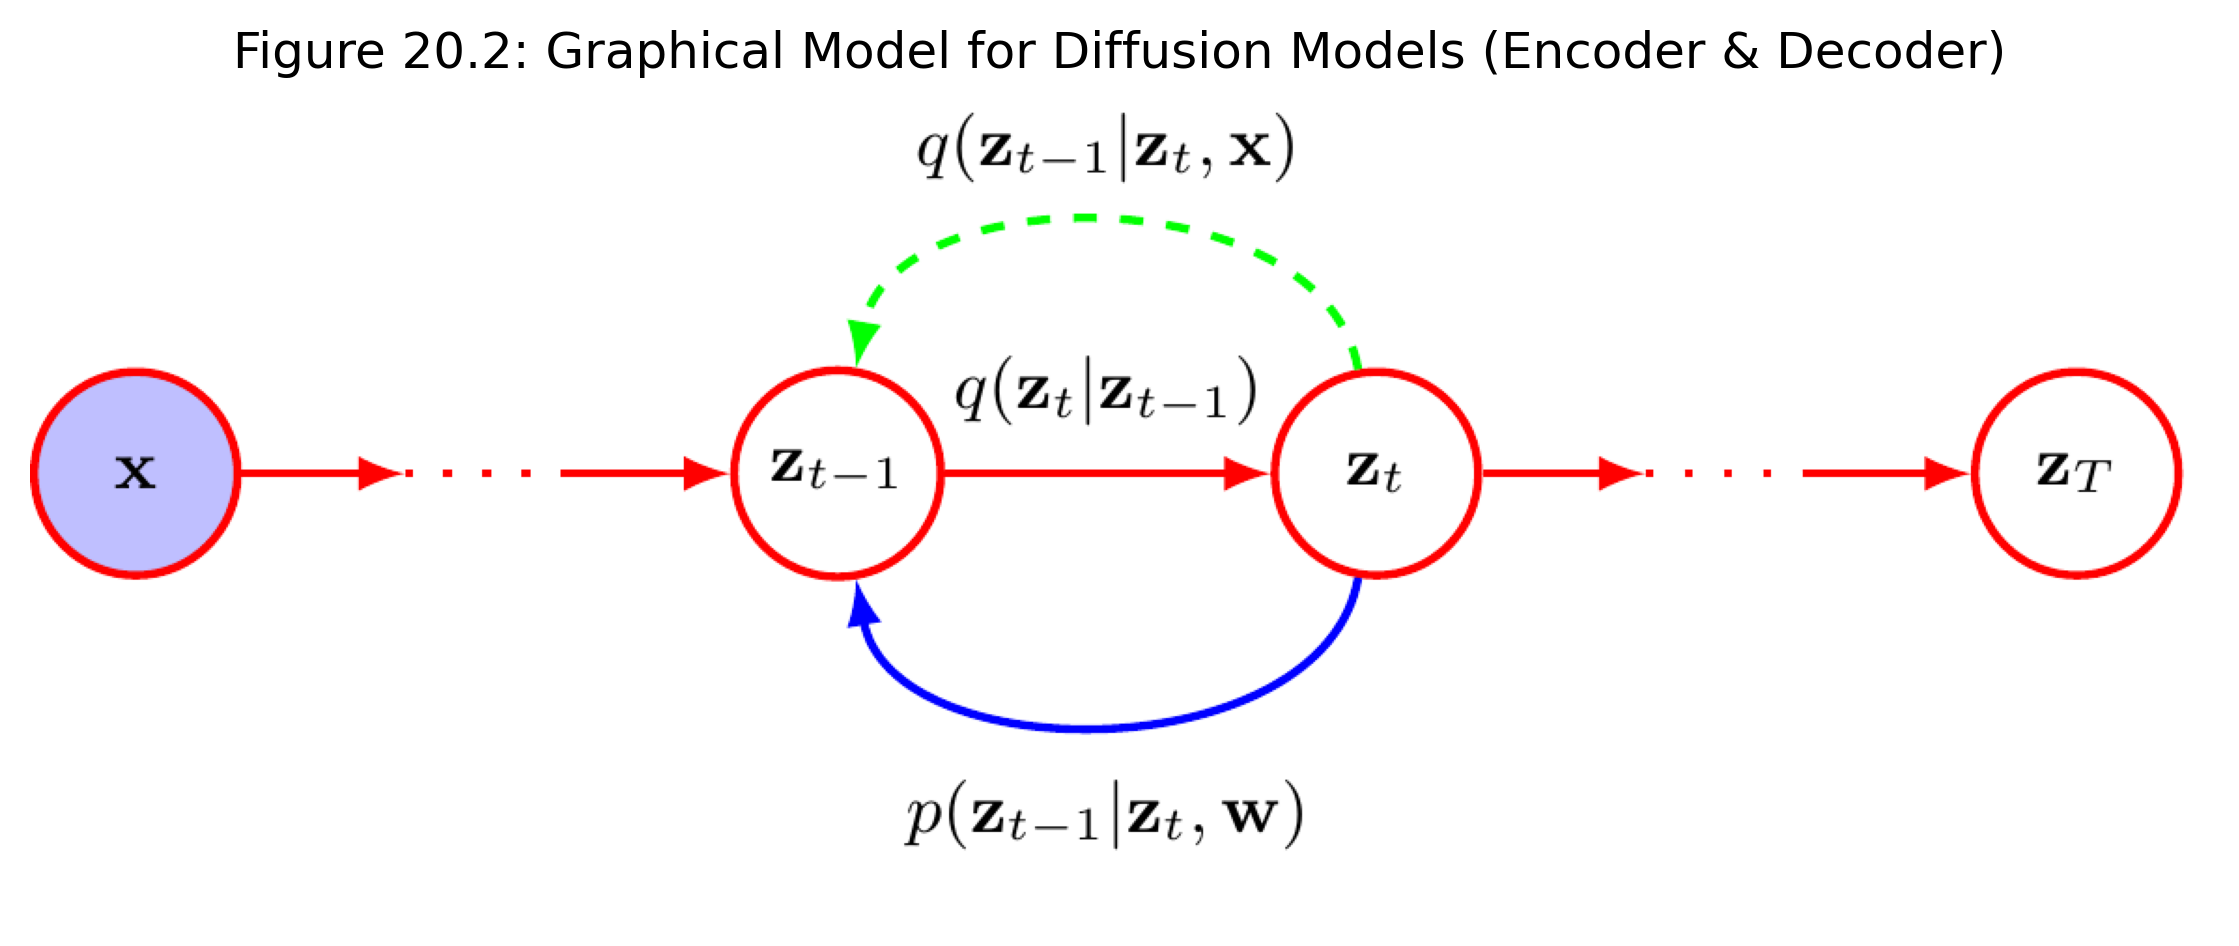

In [3]:
# 教科書図版の生成と表示: Figure 20.1 (画像劣化系列) および Figure 20.2 (グラフィカルモデル)
fig_20_1 = generate_figure_20_1(save_path="../result/Figure_20_1.png")
plt.show()

fig_20_2 = generate_figure_20_2(save_path="../result/Figure_20_2.png")
plt.show()


#### 3. ノイズスケジュール (Noise Schedules) の設計
拡散モデルの生成品質は、ノイズ注入速度 $\beta_t$ の設計に大きく依存します：

1. **線形スケジュール (Linear Schedule, Ho et al. 2020)**:
   $$
   \beta_t = \beta_{\min} + \frac{t - 1}{T - 1} (\beta_{\max} - \beta_{\min})
   $$
   通常 $T = 1000$、$\beta_{\min} = 10^{-4}$、$\beta_{\max} = 0.02$ が用いられます。
2. **コサインスケジュール (Cosine Schedule, Nichol & Dhariwal 2021)**:
   線形スケジュールは軌道の終盤で急激にデータ信号を破壊しすぎる傾向があります。コサインスケジュールは以下のように累積スケール $\bar{\alpha}_t$ を滑らかに減衰させます：
   $$
   \bar{\alpha}_t = \frac{f(t)}{f(0)}, \qquad f(t) = \cos^2\left( \frac{t/T + s}{1 + s} \frac{\pi}{2} \right)
   $$
   $$
   \beta_t = 1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}
   $$

#### 4. 逆ステップの多峰性と微小刻み極限 (Figures 20.3 & 20.4)
前向き遷移カーネル $q(\mathbf{z}_t \mid \mathbf{z}_{t-1})$ は常に単峰の正規分布ですが、**その逆方向の条件付き確率 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t)$ は一般に正規分布にはなりません**。
ベイズの定理より：
$$
q(\mathbf{z}_{t-1} \mid \mathbf{z}_t) = \frac{q(\mathbf{z}_t \mid \mathbf{z}_{t-1}) q(\mathbf{z}_{t-1})}{\int q(\mathbf{z}_t \mid \mathbf{z}_{t-1}') q(\mathbf{z}_{t-1}') d\mathbf{z}_{t-1}'}
$$
もし周辺分布 $q(\mathbf{z}_{t-1})$ が多峰性（マルチモーダル）を持つデータ分布に由来する場合、**$\beta_t$ が大きいと複数の峰から $\mathbf{z}_t$ へ到達し得るため、逆分布 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t)$ も顕著な多峰性を示します (Figure 20.3)**。

しかし、**ステップ幅が無限小の極限（$\beta_t \to 0$、すなわち $T \to \infty$）においては、局所的な近傍からの寄与のみが支配的となり、逆遷移確率 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t)$ は厳密にガウス分布に収束します (Feller 1949 の定理, Figure 20.4)**。
これこそが、逆プロセスを単純な対角ガウス分布 $p(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{w}) = \mathcal{N}(\boldsymbol{\mu}_\theta(\mathbf{z}_t, t), \sigma_t^2 \mathbf{I})$ でモデル化できる深層拡散モデルの数学的正当性の根拠です。


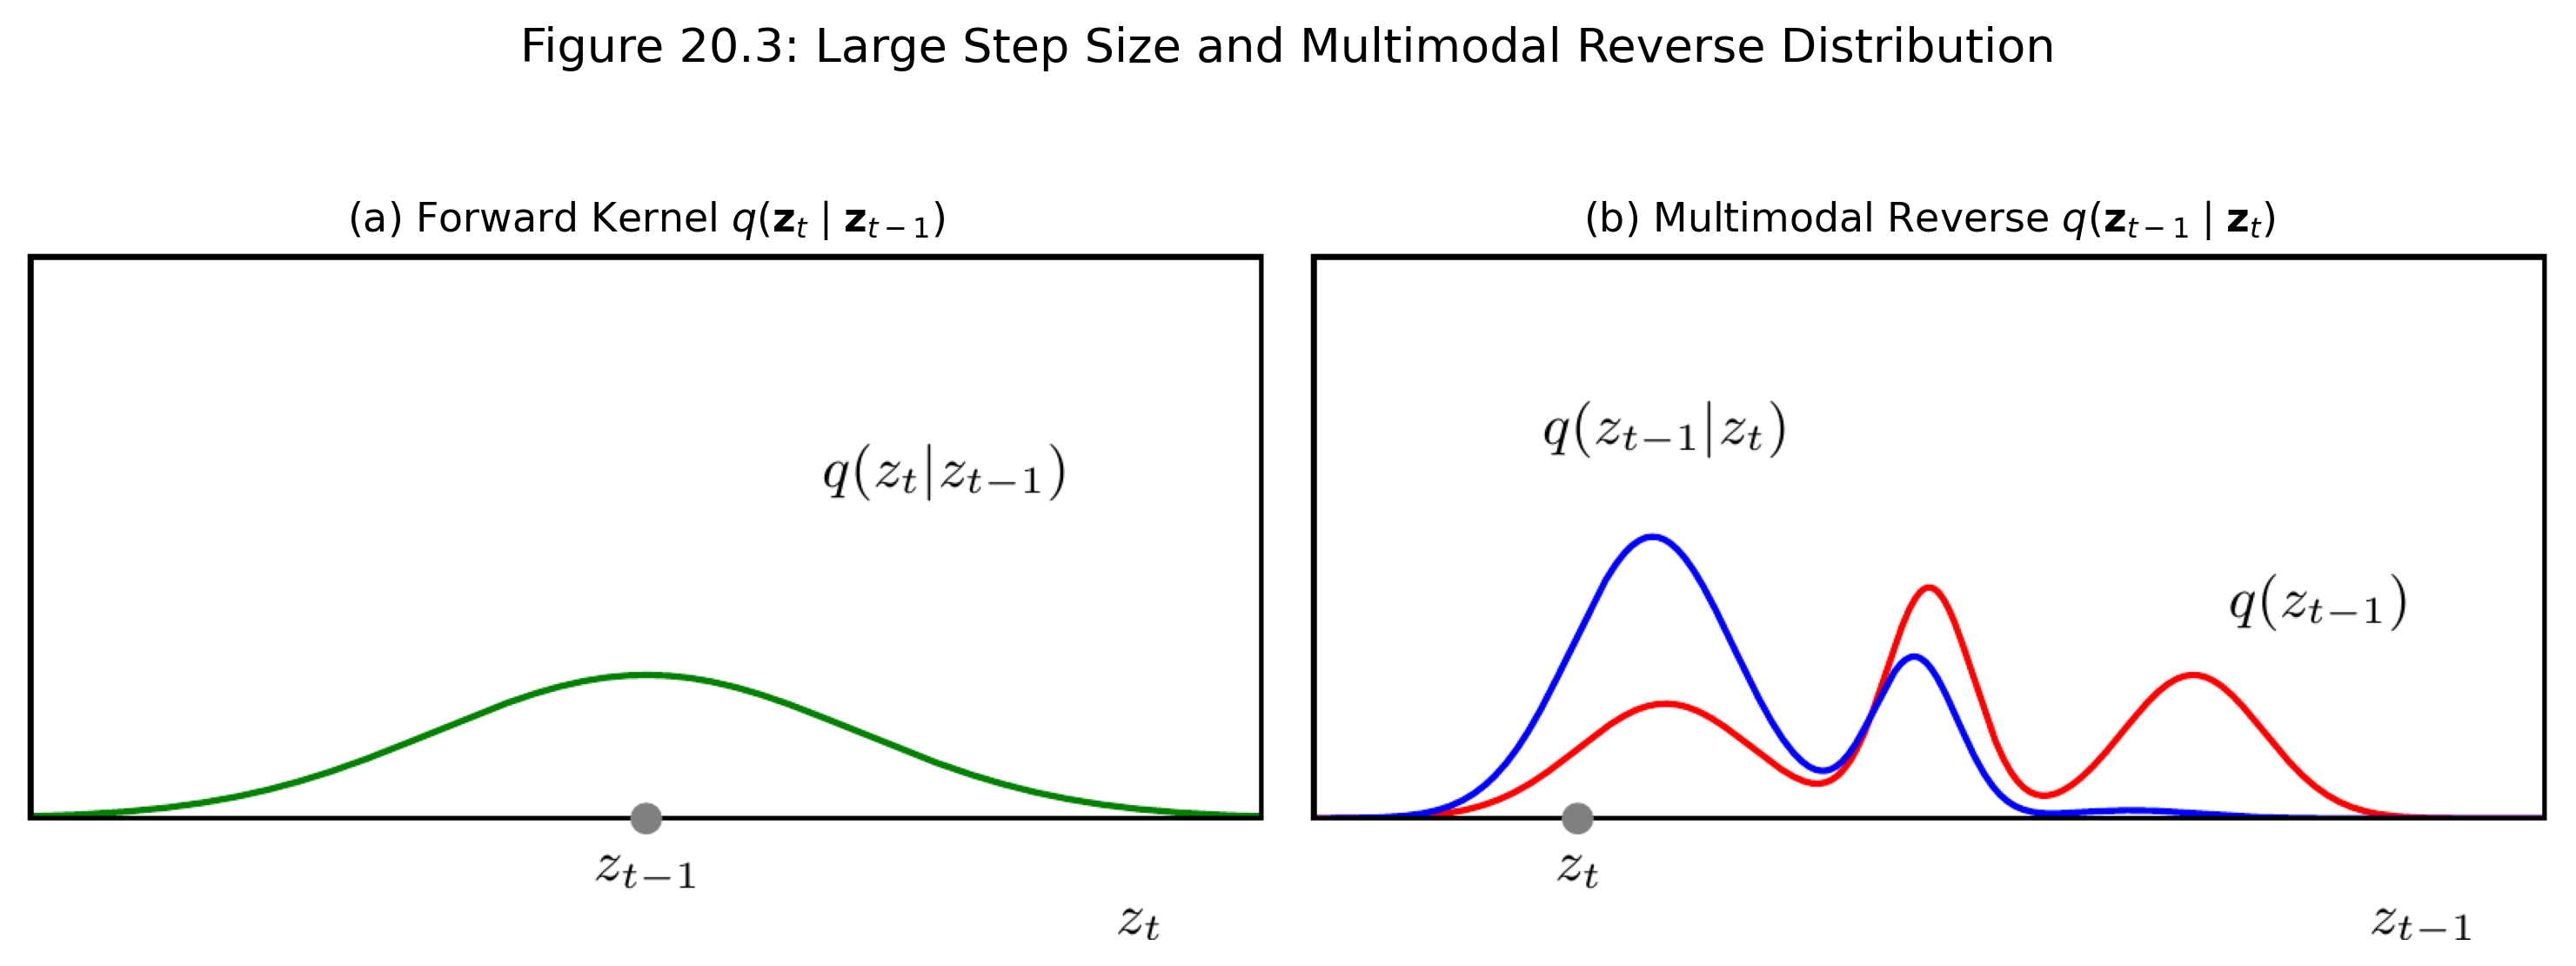

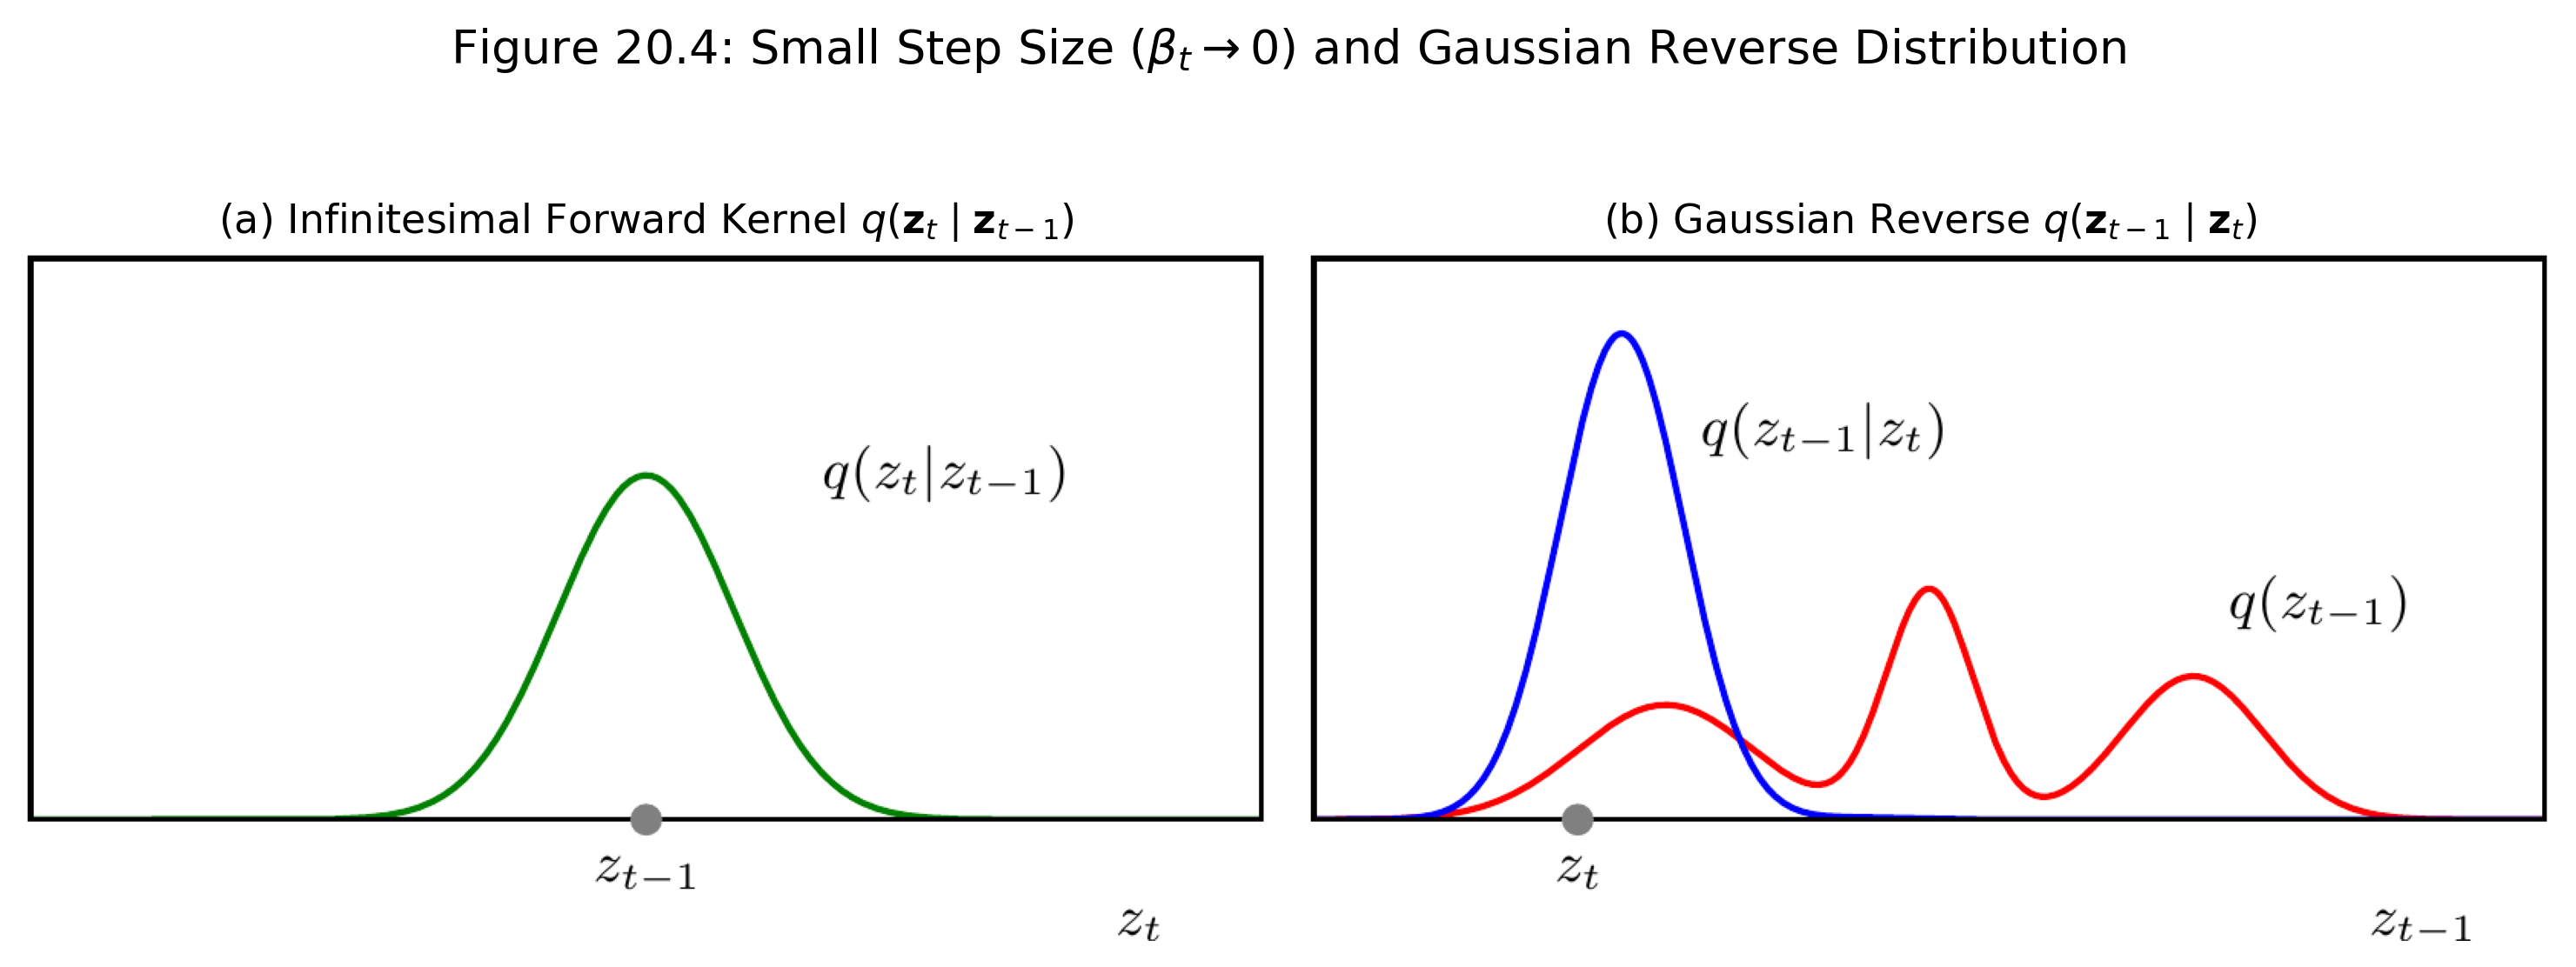

In [4]:
# 教科書図版の生成と表示: Figure 20.3 (大刻み幅の多峰性) および Figure 20.4 (微小刻み幅のガウス収束)
fig_20_3 = generate_figure_20_3(save_path="../result/Figure_20_3.png")
plt.show()

fig_20_4 = generate_figure_20_4(save_path="../result/Figure_20_4.png")
plt.show()


---

### 20.1.2 条件付き分布 (Conditional distribution)

#### 1. 任意時刻 $t$ への直接サンプリング公式 (式 20.5, 20.6)
もし前向きプロセスにおいて $\mathbf{z}_t$ を得るために $t$ 回のガウスサンプリングを逐次実行しなければならないとすると、学習時に膨大な計算コストが発生します。
しかし、ガウス分布の再生性（独立な正規確率変数の線形結合は再び正規分布に従う性質）を利用することで、**初期データ $\mathbf{x}$ から任意の時刻 $t$ の潜在変数 $\mathbf{z}_t$ を 1 ステップで解析的に直接サンプリングできます**。

まず以下の記号を定義します：
$$
\alpha_t = 1 - \beta_t \tag{20.3}
$$
$$
\bar{\alpha}_t = \prod_{s=1}^t \alpha_s \tag{20.4}
$$

このとき、初期データ $\mathbf{x}$ で条件付けた周辺分布は以下の閉形式ガウス分布となります：
$$
q(\mathbf{z}_t \mid \mathbf{x}) = \mathcal{N}\left( \mathbf{z}_t \;\middle|\; \sqrt{\bar{\alpha}_t}\mathbf{x}, \, (1 - \bar{\alpha}_t)\mathbf{I} \right) \tag{20.5}
$$

再パラメータ化（Reparameterization）表現を用いると：
$$
\mathbf{z}_t = \sqrt{\bar{\alpha}_t}\mathbf{x} + \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}) \tag{20.6}
$$

#### 2. 数学的帰納法による厳密な証明ステップ
- **ステップ 1: $t = 1$ の場合**
  定義 (20.1) より $\mathbf{z}_1 = \sqrt{\alpha_1}\mathbf{x} + \sqrt{1 - \alpha_1}\boldsymbol{\epsilon}_1$（$\boldsymbol{\epsilon}_1 \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$）。
  $\bar{\alpha}_1 = \alpha_1$ であるため、式 (20.6) は $t = 1$ で成立する。

- **ステップ 2: $t = 2$ の場合（展開のメカニズム）**
  $\mathbf{z}_2 = \sqrt{\alpha_2}\mathbf{z}_1 + \sqrt{1 - \alpha_2}\boldsymbol{\epsilon}_2$。ここに $\mathbf{z}_1$ の式を代入すると：
  $$
  \mathbf{z}_2 = \sqrt{\alpha_2}\left( \sqrt{\alpha_1}\mathbf{x} + \sqrt{1 - \alpha_1}\boldsymbol{\epsilon}_1 \right) + \sqrt{1 - \alpha_2}\boldsymbol{\epsilon}_2
  = \sqrt{\alpha_1 \alpha_2}\mathbf{x} + \left( \sqrt{\alpha_2(1 - \alpha_1)}\boldsymbol{\epsilon}_1 + \sqrt{1 - \alpha_2}\boldsymbol{\epsilon}_2 \right)
  $$
  ここで $\boldsymbol{\epsilon}_1, \boldsymbol{\epsilon}_2 \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(\mathbf{0}, \mathbf{I})$ は独立であるため、その線形結合 $a \boldsymbol{\epsilon}_1 + b \boldsymbol{\epsilon}_2$ の分散は：
  $$
  a^2 + b^2 = \alpha_2(1 - \alpha_1) + (1 - \alpha_2) = \alpha_2 - \alpha_1 \alpha_2 + 1 - \alpha_2 = 1 - \alpha_1 \alpha_2 = 1 - \bar{\alpha}_2
  $$
  よって合成されたノイズは $\sqrt{1 - \bar{\alpha}_2}\boldsymbol{\epsilon}$（$\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$）と厳密に等価となる。

- **ステップ 3: $t - 1$ から $t$ への一般化帰納**
  $\mathbf{z}_{t-1} = \sqrt{\bar{\alpha}_{t-1}}\mathbf{x} + \sqrt{1 - \bar{\alpha}_{t-1}}\boldsymbol{\epsilon}_{t-1}$ が成立すると仮定する。
  $$
  \mathbf{z}_t = \sqrt{\alpha_t}\mathbf{z}_{t-1} + \sqrt{1 - \alpha_t}\boldsymbol{\epsilon}_t
  = \sqrt{\alpha_t \bar{\alpha}_{t-1}}\mathbf{x} + \sqrt{\alpha_t(1 - \bar{\alpha}_{t-1})}\boldsymbol{\epsilon}_{t-1} + \sqrt{1 - \alpha_t}\boldsymbol{\epsilon}_t
  $$
  合成ノイズの分散は：
  $$
  \alpha_t(1 - \bar{\alpha}_{t-1}) + (1 - \alpha_t) = \alpha_t - \alpha_t \bar{\alpha}_{t-1} + 1 - \alpha_t = 1 - \alpha_t \bar{\alpha}_{t-1} = 1 - \bar{\alpha}_t
  $$
  したがって、任意の $t$ において $\mathbf{z}_t = \sqrt{\bar{\alpha}_t}\mathbf{x} + \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon}$ が厳密に成立する（証明終了）。


In [5]:
# 任意ステップ直接サンプリング公式 (式 20.5, 20.6) の数値的検証
T = 100
schedule = LinearNoiseSchedule(T=T, beta_min=1e-4, beta_max=0.02)
encoder = ForwardDiffusionEncoder(schedule=schedule)

x0 = np.array([2.5, -1.8])
t_eval = 50

# 1. 逐次マルコフステップを T 回実行して得られるサンプルの標本平均・分散
N_samples = 20000
sequential_samples = []
for _ in range(N_samples):
    curr = x0.copy()
    for s in range(1, t_eval + 1):
        curr = encoder.step(curr, t=s)
    sequential_samples.append(curr)
sequential_samples = np.array(sequential_samples)

# 2. 直接サンプリング公式 (式 20.6) による標本平均・分散
direct_samples = np.array([encoder.sample_marginal(x0, t=t_eval) for _ in range(N_samples)])

alpha_bar_t = schedule.alphas_cumprod[t_eval]
theoretical_mean = np.sqrt(alpha_bar_t) * x0
theoretical_var = 1.0 - alpha_bar_t

print(f"【時刻 t = {t_eval} における直接サンプリングと逐次シミュレーションの比較】")
print(f"  - 理論平均ベクトル       : {theoretical_mean}")
print(f"  - 逐次シミュレーション平均: {np.mean(sequential_samples, axis=0)}")
print(f"  - 直接公式サンプル平均   : {np.mean(direct_samples, axis=0)}")
print(f"  - 理論分散               : {theoretical_var:.4f}")
print(f"  - 逐次シミュレーション分散: {np.mean(np.var(sequential_samples, axis=0)):.4f}")
print(f"  - 直接公式サンプル分散   : {np.mean(np.var(direct_samples, axis=0)):.4f}")

# アサーションによる検証
assert np.allclose(np.mean(direct_samples, axis=0), theoretical_mean, atol=0.05)
assert np.allclose(np.mean(sequential_samples, axis=0), theoretical_mean, atol=0.05)
assert np.isclose(np.mean(np.var(direct_samples, axis=0)), theoretical_var, atol=0.05)
print("直接サンプリング公式の数値的一致を確認（合格）")


【時刻 t = 50 における直接サンプリングと逐次シミュレーションの比較】
  - 理論平均ベクトル       : [ 2.20394544 -1.58684072]
  - 逐次シミュレーション平均: [ 2.20536052 -1.58762144]
  - 直接公式サンプル平均   : [ 2.20120256 -1.58399189]
  - 理論分散               : 0.2228
  - 逐次シミュレーション分散: 0.2222
  - 直接公式サンプル分散   : 0.2183
直接サンプリング公式の数値的一致を確認（合格）


#### 3. 条件付き前向き事後分布 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x})$ の解析的導出 (式 20.7 〜 20.9)
次節 20.2 でデコーダ（逆プロセス）を学習する際、教師信号となるのは「**初期データ $\mathbf{x}$ をカンニングした状態で、$\mathbf{z}_t$ から 1 つ前の潜在状態 $\mathbf{z}_{t-1}$ へ戻る真の事後分布**」です。

ベイズの定理より：
$$
q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x}) = \frac{q(\mathbf{z}_t \mid \mathbf{z}_{t-1}, \mathbf{x}) q(\mathbf{z}_{t-1} \mid \mathbf{x})}{q(\mathbf{z}_t \mid \mathbf{x})}
$$
マルコフ性より $q(\mathbf{z}_t \mid \mathbf{z}_{t-1}, \mathbf{x}) = q(\mathbf{z}_t \mid \mathbf{z}_{t-1})$ であり、分子分母のすべての分布は既知のガウス分布です：
1. $q(\mathbf{z}_t \mid \mathbf{z}_{t-1}) = \mathcal{N}(\mathbf{z}_t \mid \sqrt{\alpha_t}\mathbf{z}_{t-1}, \beta_t \mathbf{I})$
2. $q(\mathbf{z}_{t-1} \mid \mathbf{x}) = \mathcal{N}(\mathbf{z}_{t-1} \mid \sqrt{\bar{\alpha}_{t-1}}\mathbf{x}, (1 - \bar{\alpha}_{t-1})\mathbf{I})$
3. $q(\mathbf{z}_t \mid \mathbf{x}) = \mathcal{N}(\mathbf{z}_t \mid \sqrt{\bar{\alpha}_t}\mathbf{x}, (1 - \bar{\alpha}_t)\mathbf{I})$

##### 指数部の平方完成（途中計算の完全展開）:
対数をとって $\mathbf{z}_{t-1}$ に依存する項を整理します：
$$
\ln q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x}) = -\frac{1}{2} \left[ \frac{\|\mathbf{z}_t - \sqrt{\alpha_t}\mathbf{z}_{t-1}\|^2}{\beta_t} + \frac{\|\mathbf{z}_{t-1} - \sqrt{\bar{\alpha}_{t-1}}\mathbf{x}\|^2}{1 - \bar{\alpha}_{t-1}} \right] + C(\mathbf{z}_t, \mathbf{x})
$$
$\mathbf{z}_{t-1}$ の二次形式と一次形式を展開すると：
$$
= -\frac{1}{2} \left[ \left( \frac{\alpha_t}{\beta_t} + \frac{1}{1 - \bar{\alpha}_{t-1}} \right) \|\mathbf{z}_{t-1}\|^2 - 2 \left( \frac{\sqrt{\alpha_t}}{\beta_t}\mathbf{z}_t + \frac{\sqrt{\bar{\alpha}_{t-1}}}{1 - \bar{\alpha}_{t-1}}\mathbf{x} \right)^T \mathbf{z}_{t-1} \right]
$$

- **事後分散 $\tilde{\beta}_t$ の同定**:
  二次形式の係数を共通通分すると：
  $$
  \frac{\alpha_t}{\beta_t} + \frac{1}{1 - \bar{\alpha}_{t-1}} = \frac{\alpha_t(1 - \bar{\alpha}_{t-1}) + \beta_t}{\beta_t(1 - \bar{\alpha}_{t-1})}
  = \frac{\alpha_t - \bar{\alpha}_t + 1 - \alpha_t}{\beta_t(1 - \bar{\alpha}_{t-1})} = \frac{1 - \bar{\alpha}_t}{\beta_t(1 - \bar{\alpha}_{t-1})}
  $$
  したがって、事後分散 $\tilde{\beta}_t$ はその逆数となり：
  $$
  \tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \beta_t \tag{20.9}
  $$

- **事後平均 $\tilde{\boldsymbol{\mu}}_t(\mathbf{z}_t, \mathbf{x})$ の同定**:
  一次形式に $\tilde{\beta}_t$ を掛けると：
  $$
  \tilde{\boldsymbol{\mu}}_t(\mathbf{z}_t, \mathbf{x}) = \tilde{\beta}_t \left( \frac{\sqrt{\alpha_t}}{\beta_t}\mathbf{z}_t + \frac{\sqrt{\bar{\alpha}_{t-1}}}{1 - \bar{\alpha}_{t-1}}\mathbf{x} \right)
  = \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1 - \bar{\alpha}_t} \mathbf{x} + \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} \mathbf{z}_t \tag{20.8}
  $$

以上より、条件付き事後分布は厳密に以下で与えられます：
$$
q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x}) = \mathcal{N}\left( \mathbf{z}_{t-1} \;\middle|\; \tilde{\boldsymbol{\mu}}_t(\mathbf{z}_t, \mathbf{x}), \, \tilde{\beta}_t \mathbf{I} \right) \tag{20.7}
$$


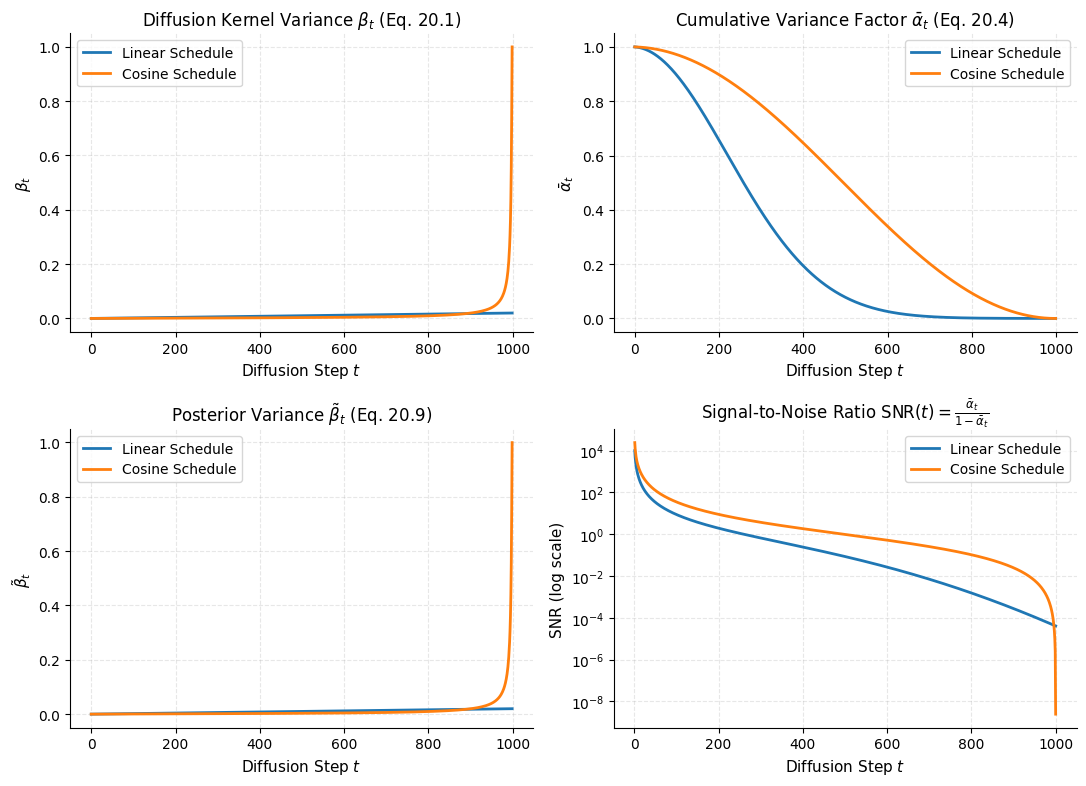

In [6]:
# 条件付き事後分布のパラメータおよびノイズスケジュールの可視化
T = 1000
lin_sched = LinearNoiseSchedule(T=T, beta_min=1e-4, beta_max=0.02)
cos_sched = CosineNoiseSchedule(T=T)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 8))

# 1. beta_t
ax1.plot(lin_sched.betas[1:], label='Linear Schedule', color='#1f77b4', lw=2)
ax1.plot(cos_sched.betas[1:], label='Cosine Schedule', color='#ff7f0e', lw=2)
ax1.set_xlabel('Diffusion Step $t$', fontsize=11)
ax1.set_ylabel(r'$\beta_t$', fontsize=11)
ax1.set_title(r'Diffusion Kernel Variance $\beta_t$ (Eq. 20.1)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. alpha_bar_t
ax2.plot(lin_sched.alphas_cumprod[1:], label='Linear Schedule', color='#1f77b4', lw=2)
ax2.plot(cos_sched.alphas_cumprod[1:], label='Cosine Schedule', color='#ff7f0e', lw=2)
ax2.set_xlabel('Diffusion Step $t$', fontsize=11)
ax2.set_ylabel(r'$\bar{\alpha}_t$', fontsize=11)
ax2.set_title(r'Cumulative Variance Factor $\bar{\alpha}_t$ (Eq. 20.4)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Posterior Variance \tilde{\beta}_t
ax3.plot(lin_sched.posterior_variance[1:], label='Linear Schedule', color='#1f77b4', lw=2)
ax3.plot(cos_sched.posterior_variance[1:], label='Cosine Schedule', color='#ff7f0e', lw=2)
ax3.set_xlabel('Diffusion Step $t$', fontsize=11)
ax3.set_ylabel(r'$\tilde{\beta}_t$', fontsize=11)
ax3.set_title(r'Posterior Variance $\tilde{\beta}_t$ (Eq. 20.9)', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Signal-to-Noise Ratio (SNR) in log-scale
t_axis = np.arange(1, T + 1)
ax4.semilogy(t_axis, lin_sched.snr[1:], label='Linear Schedule', color='#1f77b4', lw=2)
ax4.semilogy(t_axis, cos_sched.snr[1:], label='Cosine Schedule', color='#ff7f0e', lw=2)
ax4.set_xlabel('Diffusion Step $t$', fontsize=11)
ax4.set_ylabel('SNR (log scale)', fontsize=11)
ax4.set_title(r'Signal-to-Noise Ratio $\mathrm{SNR}(t) = \frac{\bar{\alpha}_t}{1 - \bar{\alpha}_t}$', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## 20.1 節のまとめ (Section Summary)

本節では、深層拡散モデルにおける「前向きエンコーダ（Forward Encoder）」の基礎理論と数理的メカニズムを解明しました：

1. **マルコフ拡散過程と分散保存 (式 20.1, 20.2)**:
   - 前向きプロセスはパラメータを持たない固定されたマルコフ連鎖であり、各ステップで平均を $\sqrt{1 - \beta_t}$ 倍に縮小しつつ分散 $\beta_t$ のガウスノイズを注入することで、全体の分散を保存しながらデータを純粋な等方性ガウスノイズ $\mathcal{N}(\mathbf{0}, \mathbf{I})$ へと融解させます。

2. **微小刻み極限におけるガウス収束 (Feller の定理, Figures 20.3, 20.4)**:
   - 大刻み幅（大きな $\beta_t$）では逆方向の遷移 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t)$ は複雑な多峰性を示しますが、ステップ幅を無限小（$\beta_t \to 0$）にする極限では、逆遷移も厳密にガウス分布に収束します。これにより、デコーダをガウス分布でパラメータ化することが理論的に正当化されます。

3. **直接サンプリング公式 (式 20.5, 20.6)**:
   - 累積分散係数 $\bar{\alpha}_t = \prod_{s=1}^t (1 - \beta_s)$ を用いることで、初期データ $\mathbf{x}$ から任意の時刻 $t$ の潜在状態 $\mathbf{z}_t$ を 1 回のサンプリング $\mathbf{z}_t = \sqrt{\bar{\alpha}_t}\mathbf{x} + \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon}$ で直接生成でき、計算量が $O(t)$ から $O(1)$ に劇的に圧縮されます。

4. **条件付き前向き事後分布 (式 20.7 〜 20.9)**:
   - 真のデータ $\mathbf{x}$ が既知である場合、$\mathbf{z}_t$ から 1 つ前の状態 $\mathbf{z}_{t-1}$ へ戻る事後分布 $q(\mathbf{z}_{t-1} \mid \mathbf{z}_t, \mathbf{x})$ は厳密に閉形式のガウス分布となり、その平均 $\tilde{\boldsymbol{\mu}}_t$ と分散 $\tilde{\beta}_t$ が導出されました。
   - この事後分布は、次節 20.2 でニューラルネットワーク（逆向きデコーダ）を学習する際の理想的な教師目標（Ground Truth Target）として機能します。
